In [1]:
import math
import cmath
import graphviz
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv
from openpyxl import load_workbook
from array import array

import qiskit as q
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister, transpile
from qiskit.visualization import * 
from qiskit.quantum_info import Pauli, SparsePauliOp, Operator
from qiskit.transpiler import CouplingMap
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.circuit.library import *
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2 as Estimator, SamplerV2 as Sampler

In [2]:
# Save an IBM Quantum account and set it as your default account.
API_Token = '13d9540e280b61b7a4254fcdb05516180957df07523dfef1924f7d9363699a51826b42e7a063b3fb685f295f6d27f8ff61810a97f503a704c07bc959d6cc6e3f'
QiskitRuntimeService.save_account(
    channel = "ibm_quantum",
    
    instance = "ibm-q-hub-ntu/chen-hong-bin/default",
    token = API_Token,
    set_as_default = True,
    # Use `overwrite=True` if you're updating your token.
    overwrite = True,
)

# Load saved credentials
service = QiskitRuntimeService()

#For real Device
#backend = service.least_busy(operational=True, simulator=False)
backend_nazca = service.backend("ibm_kyiv")
noise_model = NoiseModel.from_backend(backend_nazca)

# Get basis gates from noise model
basis_gates = noise_model.basis_gates

#For FakeSimulator
#backend = FakeManilaV2()

# Get coupling map from backend
coupling_map = [[0, 1], [1, 2], [3, 2], [3, 4]]

#For Aer
backend = AerSimulator(noise_model=noise_model,
                       coupling_map=coupling_map,
                       basis_gates=basis_gates)
#backend = AerSimulator()
#backend = AerSimulator.from_backend(backend_nazca)

backendqubitNum = backend.num_qubits

In [3]:
# 讀取 CSV 檔案（支援複數）
file_path = "matrix_B_inv.csv"
B_inv = np.genfromtxt(file_path, delimiter=",", dtype=complex)


# 顯示讀取結果
print("讀取的矩陣：")
print(B_inv)

讀取的矩陣：
[[ 1.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j]
 [ 5.29582091e-03+0.j  1.00210956e+00+0.j -1.43035621e-02+0.j
  -5.70488980e-03+0.j  9.19009813e-03+0.j -5.00644508e-03+0.j
   2.36855755e-02+0.j  1.03904091e-02+0.j -7.32229090e-03+0.j
   8.09999823e-03+0.j  2.10590369e-02+0.j -1.57739487e-03+0.j
   6.10106761e-03+0.j -4.68223124e-03+0.j -1.54727726e-03+0.j
  -5.29634606e-03+0.j]
 [ 2.02072071e-02+0.j -3.61377854e-02+0.j  9.90797409e-01+0.j
   7.05368102e-03+0.j -2.45897019e-02+0.j  4.59120452e-02+0.j
   2.37718315e-02+0.j -2.22151424e-03+0.j -2.57313404e-02+0.j
   3.11840613e-02+0.j  2.30755931e-02+0.j -1.05762122e-03+0.j
  -3.49703886e-03+0.j  5.97818293e-03+0.j  3.39793709e-03+0.j
   3.91815776e-03

In [4]:
#Calculate observable X, Y, Z
a_i = np.array([[1, 0, 0, 0]])
a_x = np.array([[0, 1, 0, 0]])
a_y = np.array([[0, 0, 1, 0]])
a_z = np.array([[0, 0, 0, 1]])
a = {'i':a_i, 'x':a_x, 'y':a_y, 'z':a_z}
aa = {}
qq = {}
for f, first in a.items():
    for s, second in a.items():
        a_mix = np.kron(first, second)
        aa.update({f'a_{f}{s}':a_mix})
        q_mix = np.matmul(a_mix, B_inv)
        qq.update({f'q_{f}{s}':q_mix})
        
        print(f'a_{f}{s}:', a_mix)
        print(f'q_{f}{s}:', q_mix)
        print('\n')

a_ii: [[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]
q_ii: [[1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
  0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]]


a_ix: [[0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]
q_ix: [[ 0.00529582+0.j  1.00210956+0.j -0.01430356+0.j -0.00570489+0.j
   0.0091901 +0.j -0.00500645+0.j  0.02368558+0.j  0.01039041+0.j
  -0.00732229+0.j  0.0081    +0.j  0.02105904+0.j -0.00157739+0.j
   0.00610107+0.j -0.00468223+0.j -0.00154728+0.j -0.00529635+0.j]]


a_iy: [[0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]]
q_iy: [[ 0.02020721+0.j -0.03613779+0.j  0.99079741+0.j  0.00705368+0.j
  -0.0245897 +0.j  0.04591205+0.j  0.02377183+0.j -0.00222151+0.j
  -0.02573134+0.j  0.03118406+0.j  0.02307559+0.j -0.00105762+0.j
  -0.00349704+0.j  0.00597818+0.j  0.00339794+0.j  0.00391816+0.j]]


a_iz: [[0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]]
q_iz: [[ 4.15525308e-04+0.j  3.47923146e-03+0.j -1.09713262e-03+0.j
   1.00823011e+00+0.j -1.60325311e-03+0.j -2.01417603e-02+0.j
  -2.32357434e-02+0.j  7.399

In [5]:
# 讀取 CSV 檔案
file_path = "inv_weight_c.csv"
inv_weight_c = np.genfromtxt(file_path, delimiter=",", dtype=complex)

# 顯示讀取結果
print(inv_weight_c)

[ 1.00682583e+00+0.j  1.28798170e-03+0.j  4.69248367e-04+0.j
  5.66943632e-04+0.j -1.56883920e-03+0.j -5.01865398e-03+0.j
 -2.61082436e-03+0.j -2.28680072e-04+0.j  2.09598916e-03+0.j
  3.93461328e-03+0.j  3.61662876e-03+0.j -1.75306845e-03+0.j
 -3.46130131e-03+0.j -8.27821282e-04+0.j -3.77485193e-04+0.j
 -2.95056580e-03+0.j]


In [6]:
# Function to generate measurement circuits
def generate_pauli_circuits(index):
    circuits = {
        "I": QuantumCircuit(2, 2),
        "X": QuantumCircuit(2, 2),
        "Y": QuantumCircuit(2, 2),
        "Z": QuantumCircuit(2, 2),
    }
    # X-measurement
    circuits["X"].x(index)
    # Y-measurement
    circuits["Y"].y(index)
    # Z-measurement
    circuits["Z"].z(index)

    return circuits

# Store the measurement circuits in a dictionary
PauliTwirling = {}
for q0_label, q0 in generate_pauli_circuits(0).items():
    for q1_label, q1 in generate_pauli_circuits(1).items():
        pauli_comb = q.circuit.QuantumCircuit.compose(q0, q1)
        PauliTwirling.update({f"{q0_label}{q1_label}": pauli_comb})
print(PauliTwirling)

{'II': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x00000285BE4CF460>, 'IX': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x00000285BE4CF5B0>, 'IY': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x00000285BE4CF700>, 'IZ': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x00000285BE4CF850>, 'XI': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x00000285EDCE2FA0>, 'XX': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x00000285BE4CF820>, 'XY': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x00000285BE4CF490>, 'XZ': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x00000285BE4CFE20>, 'YI': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x00000285BE4D6550>, 'YX': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x00000285BE4D6370>, 'YY': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x00000285BE4D6820>, 'YZ': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x00000285BE4D69A0>, 'ZI

In [7]:
#Build Four Initial State |0>, |1>, |0>+|1>, |0>-i|1>
qreg = QuantumRegister(2, 'q')
creg = ClassicalRegister(2, 'c')

#Cnot gate
Cnotgate = QuantumCircuit(qreg, creg)
Cnotgate.cx(0, 1)

In [9]:
Mitigation_circuit = {}
for channel, cir in PauliTwirling.items():
    AddCnot = q.circuit.QuantumCircuit.compose(cir, Cnotgate)
    Mitigation_circuit.update({channel:AddCnot})

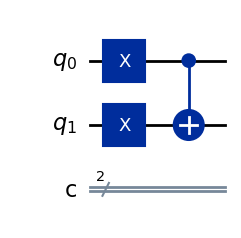

In [10]:
Mitigation_circuit['XX'].draw(output='mpl') 

In [11]:
# Store the measurement circuits in a dictionary
Measurement = {}
pau = ['I', 'X', 'Y', 'Z']
for i in pau:
    for j in pau:
        meascomb = Pauli('I' * 28 + j + i) 
        Measurement.update({f'meas{j}{i}':meascomb})
print(Measurement)

{'measII': Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIII'), 'measXI': Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIXI'), 'measYI': Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIYI'), 'measZI': Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIZI'), 'measIX': Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIIX'), 'measXX': Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIXX'), 'measYX': Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIYX'), 'measZX': Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIZX'), 'measIY': Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIIY'), 'measXY': Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIXY'), 'measYY': Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIYY'), 'measZY': Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIZY'), 'measIZ': Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIIZ'), 'measXZ': Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIXZ'), 'measYZ': Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIYZ'), 'measZZ': Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIZZ')}


In [12]:
estimator = Estimator(mode=backend)

job_origin = {}
job_pec = {}
for MeasName, Measure in Measurement.items():
    CirTran_origin = q.compiler.transpile(Cnotgate, backend=backend, optimization_level=0)
    job_origin.update({MeasName:estimator.run([(CirTran_origin, Measure)])})
    job_pec_subset = {}
    for CirName, pec_cir in Mitigation_circuit.items():
        CirTran_pec = q.compiler.transpile(pec_cir, backend=backend, optimization_level=0)
        job_pec_subset.update({CirName:estimator.run([(CirTran_pec, Measure)])})
    job_pec.update({MeasName:job_pec_subset})

In [13]:
origin_result = {}
for Meas, Originjob in job_origin.items():
    res = Originjob.result()
    origin_result.update({Meas:res[0].data.evs})
    
pec_result = {}
for Meas, Pecjob in job_pec.items():
    result = []
    for pauli, Pjob in Pecjob.items():
        res = Pjob.result()
        result.append(res[0].data.evs)
    pec_result.update({Meas:result})

print(origin_result)
print(pec_result)

{'measII': array(1.), 'measXI': array(-0.01416016), 'measYI': array(-0.01123047), 'measZI': array(0.96533203), 'measIX': array(0.03125), 'measXX': array(0.02246094), 'measYX': array(0.02978516), 'measZX': array(-0.00390625), 'measIY': array(0.00097656), 'measXY': array(0.00244141), 'measYY': array(-0.00830078), 'measZY': array(0.01660156), 'measIZ': array(0.98486328), 'measXZ': array(-0.01318359), 'measYZ': array(-0.03417969), 'measZZ': array(0.95751953)}
{'measII': [array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.)], 'measXI': [array(0.00537109), array(0.03027344), array(-0.00585938), array(-0.00390625), array(0.02929688), array(0.02294922), array(0.00830078), array(0.00927734), array(0.), array(0.01367188), array(-0.01611328), array(0.01025391), array(0.00244141), array(-0.00488281), array(0.00244141), array(0.00585938)], 'measYI': [array(-0.00244141), array(-0

In [14]:
avg_pec_result = {}
for meas, result in pec_result.items():
    avg_pec_result.update({meas:sum(result * inv_weight_c)})
avg_pec_result

{'measII': (0.9999999952519996+0j),
 'measXI': (0.005211777303421387+0j),
 'measYI': (-0.002154610870179687+0j),
 'measZI': (0.9679737411089169+0j),
 'measIX': (0.027774215933873535+0j),
 'measXX': (0.0037505647339384765+0j),
 'measYX': (-0.01077226985123047+0j),
 'measZX': (-0.005024134124930664+0j),
 'measIY': (-0.00902262378567627+0j),
 'measXY': (0.014234593673774897+0j),
 'measYY': (-0.007574148039837888+0j),
 'measZY': (0.022790324252106437+0j),
 'measIZ': (0.9883401998225364+0j),
 'measXZ': (0.037837458826292476+0j),
 'measYZ': (0.006376898938737305+0j),
 'measZZ': (0.9477537018353507+0j)}

In [15]:
compare = {}
for meas, result in avg_pec_result.items():
    difference = abs(origin_result[meas]) - abs(result)
    print(f'{meas} : {abs(origin_result[meas])} - {abs(result)} = {difference}')
    compare.update({meas:difference})
compare

measII : 1.0 - 0.9999999952519996 = 4.7480004372602025e-09
measXI : 0.01416015625 - 0.005211777303421387 = 0.008948378946578614
measYI : 0.01123046875 - 0.002154610870179687 = 0.009075857879820314
measZI : 0.96533203125 - 0.9679737411089169 = -0.002641709858916874
measIX : 0.03125 - 0.027774215933873535 = 0.0034757840661264645
measXX : 0.0224609375 - 0.0037505647339384765 = 0.018710372766061523
measYX : 0.02978515625 - 0.01077226985123047 = 0.01901288639876953
measZX : 0.00390625 - 0.005024134124930664 = -0.0011178841249306643
measIY : 0.0009765625 - 0.00902262378567627 = -0.00804606128567627
measXY : 0.00244140625 - 0.014234593673774897 = -0.011793187423774897
measYY : 0.00830078125 - 0.007574148039837888 = 0.0007266332101621116
measZY : 0.0166015625 - 0.022790324252106437 = -0.006188761752106437
measIZ : 0.98486328125 - 0.9883401998225364 = -0.0034769185725364027
measXZ : 0.01318359375 - 0.037837458826292476 = -0.024653865076292476
measYZ : 0.0341796875 - 0.006376898938737305 = 0.027

{'measII': 4.7480004372602025e-09,
 'measXI': 0.008948378946578614,
 'measYI': 0.009075857879820314,
 'measZI': -0.002641709858916874,
 'measIX': 0.0034757840661264645,
 'measXX': 0.018710372766061523,
 'measYX': 0.01901288639876953,
 'measZX': -0.0011178841249306643,
 'measIY': -0.00804606128567627,
 'measXY': -0.011793187423774897,
 'measYY': 0.0007266332101621116,
 'measZY': -0.006188761752106437,
 'measIZ': -0.0034769185725364027,
 'measXZ': -0.024653865076292476,
 'measYZ': 0.027802788561262694,
 'measZZ': 0.009765829414649319}